In [3]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from mlxtend.plotting import plot_decision_regions
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split


import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam

In [5]:
X,y = make_moons(100,noise=0.25,random_state =2)

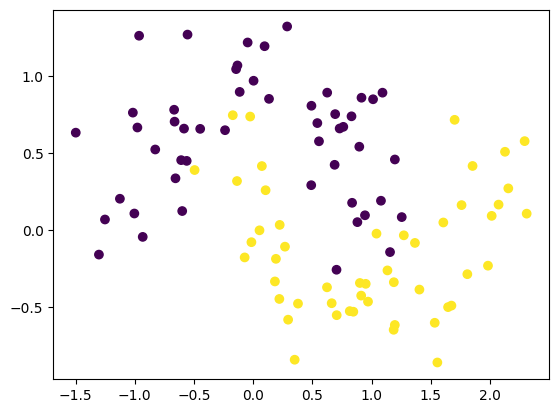

In [6]:
plt.scatter(X[:,0],X[:,1], c=y)
plt.show()

In [7]:
# firstly we made An ANN
model = Sequential()
model.add(Dense(128,input_shape=(2,),activation='tanh'))
model.add(Dense(128,activation='relu'))
model.add(Dense(1,activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [8]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,025 (66.50 KB)

 Trainable params: 17,025 (66.50 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
adam =Adam(learning_rate=0.01)
model.compile(adam,loss='binary_crossentropy',metrics=['accuracy'])

In [11]:
history =model.fit(X,y,epochs=2000,validation_split=0.2,verbose=0)

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 10s 1ms/step


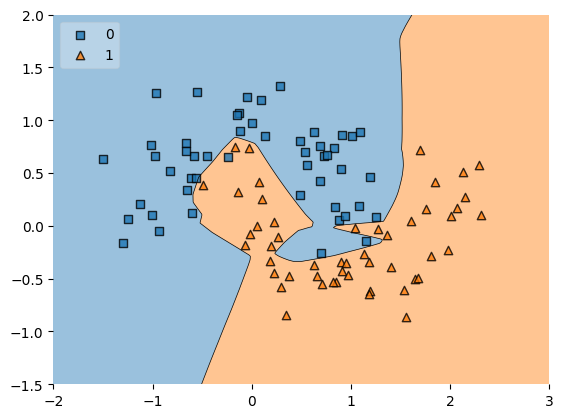

In [12]:
plot_decision_regions(X,y.astype('int'),clf =model,legend=2)
plt.xlim(-2,3)                 # saf pata lg raha hai ky overitting ho rhi hai because data ky minute patterns ko b wo dekh rha hai
plt.ylim(-1.5,2)
plt.show()

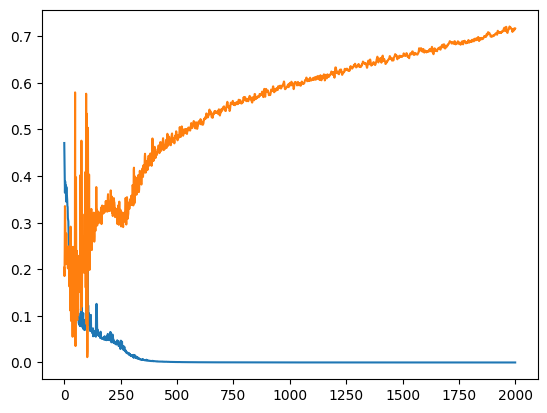

In [14]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.show()

In [16]:
model2 =Sequential()
model2.add(Dense(128,input_shape=(2,),activation='relu',kernel_regularizer =tf.keras.regularizers.l2(0.03)))
model2.add(Dense(128,activation='relu',kernel_regularizer=tf.keras.regularizers.l2(0.03)))
model2.add(Dense(1,activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [17]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 51,077 (199.52 KB)

 Trainable params: 17,025 (66.50 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 34,052 (133.02 KB)

In [18]:
adam =Adam(learning_rate=0.01)
model2.compile(adam,loss='binary_crossentropy',metrics=['accuracy'])

In [19]:
history =model2.fit(X,y,epochs=2000,validation_split=0.2,verbose=0)

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 10s 1ms/step


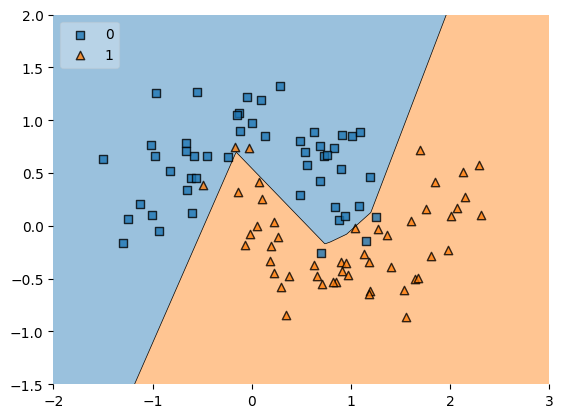

In [21]:
plot_decision_regions(X,y.astype('int'),clf =model2,legend=2)
plt.xlim(-2,3)                 # saf pata lg raha hai ky overitting ho rhi hai because data ky minute patterns ko b wo dekh rha hai
plt.ylim(-1.5,2)
plt.show()

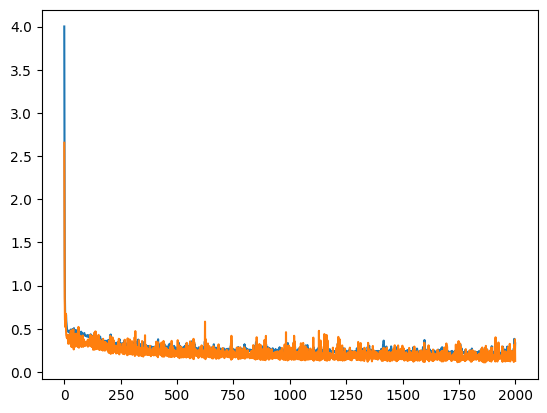

In [22]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.show()

In [26]:
model.get_weights()[0].reshape(256)

array([ 0.0801608 ,  0.52077085, -0.05734295, -0.43052432,  0.28485793,
       -0.52644616, -0.7750886 , -0.35425594,  0.29465365,  0.26167557,
       -0.40149245, -0.46068206,  0.07472504,  0.7138436 ,  0.25256407,
       -0.23666765, -0.31762105, -0.18224384,  0.3214568 ,  0.31641406,
       -0.70150954, -0.23285247,  0.3124417 , -0.09281153,  0.1183698 ,
       -0.39200428,  0.25876266,  0.22233239, -0.66766125,  0.26482832,
        0.30933106, -0.25087002,  0.29415694,  0.44398192,  0.32888564,
        0.7486691 , -0.72425383,  0.1984267 , -0.08576111, -0.22017959,
        0.36418858,  0.66600454,  0.01177391, -0.75657725, -0.5534528 ,
       -0.38205284,  0.13263594, -0.01570918,  0.3932217 ,  0.151673  ,
        0.27821684, -0.45038593, -0.47303003, -0.23125012, -0.09398957,
       -0.20976876,  0.30316484,  0.2360192 ,  0.76061577, -0.24349813,
        0.22513326, -0.2929811 , -0.21539557,  0.0217538 ,  0.28807917,
        0.13136594,  0.07859189,  0.15209532,  0.45959026,  0.11

In [27]:
model1_weights_layer1 =model.get_weights()[0].reshape(256)
model2_weights_layer2 =model2.get_weights()[0].reshape(256)

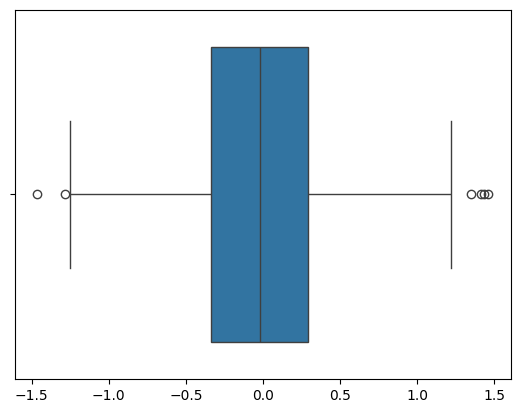

In [28]:
sns.boxplot(x=model1_weights_layer1)
plt.show()

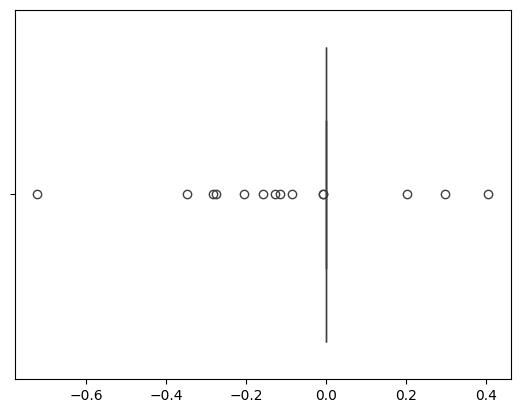

In [29]:
sns.boxplot(x=model2_weights_layer2)
plt.show()

In [30]:
model1_weights_layer1.max()

np.float32(1.4615299)

In [31]:
model1_weights_layer1.min()

np.float32(-1.4631687)

In [32]:
model2_weights_layer2.max()

np.float32(0.4064436)

In [33]:
model2_weights_layer2.min()

np.float32(-0.7226652)

/tmp/ipython-input-2692848403.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(model2_weights_layer2)


<Axes: ylabel='Count'>

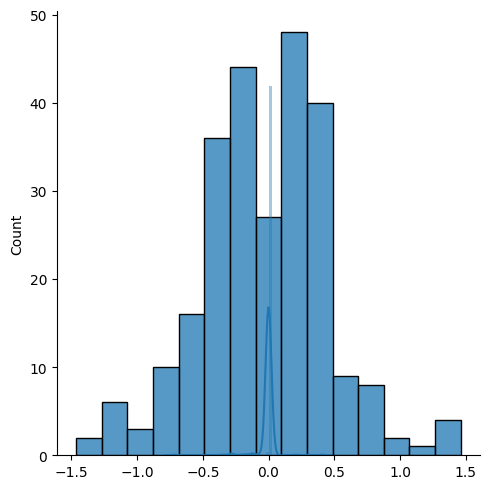

In [35]:
sns.displot(model1_weights_layer1)
sns.distplot(model2_weights_layer2)